In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

plt.style.use('seaborn-v0_8')
plt.rc('axes', titlesize=10)

In [2]:
lstx = (7, 10.3, 13.7, 16.6, 19.8, 22)
lsty = (479, 503, 487, 470, 458, 412)
# Construir o DataFrame e nomear as colunas
df = pd.DataFrame(list(zip(lstx, lsty)),
                  columns=["x", "y"])
x = df['x']
y = df['y']

In [3]:
#Proceso de regressão 
x = sm.add_constant(x)
#fit linear regression model
modelo = sm.OLS(y, x).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     6.950
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0578
Time:                        11:40:11   Log-Likelihood:                -25.637
No. Observations:                   6   AIC:                             55.27
Df Residuals:                       4   BIC:                             54.86
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        533.6984     26.328     20.271      0.0

/home/thomas/Development/Git/statistical-inference-modeling/.venv/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


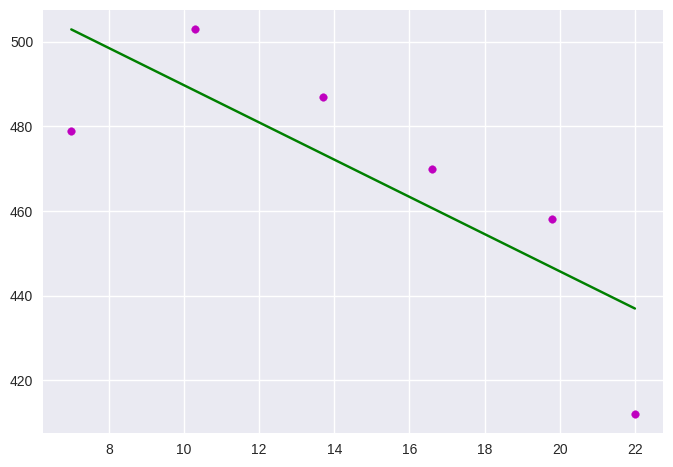

In [4]:
x = df['x']
y = df['y']
yp = 533.6984 - 4.3981 * x
plt.plot(x, yp, color="g")
plt.scatter(x, y, color="m", marker="o", s=30)
plt.grid(True)
x = sm.add_constant(x)

/tmp/ipykernel_15221/1695721934.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


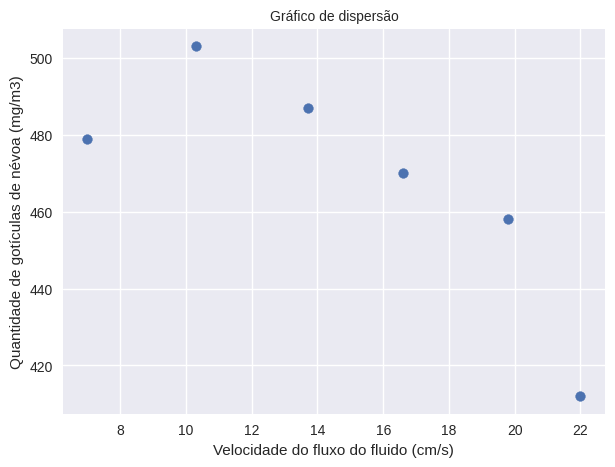

In [5]:
x = df['x']
y = df['y']
#@title Resposta a)
plt.rcParams.update({'figure.figsize': (7, 5), 'figure.dpi': 100})
plt.scatter(x, y)
plt.xlabel('Velocidade do fluxo do fluido (cm/s)')
plt.ylabel('Quantidade de gotículas de névoa (mg/m3)')
plt.title('Gráfico de dispersão')
plt.legend()
plt.grid(True)
plt.show()

Visto que os dados estão muito afastados da reta e que apresentam uma semelhança com um polinómio quadrático, é necessário criar as características do polinomio antes de realizar o ajuste.

In [6]:
x = df['x']
y = df['y']
x = sm.add_constant(x)
#Manter x + constant
from sklearn.preprocessing import PolynomialFeatures

#definir o valor de k, isto é o grau do polinômio
polynomial_features = PolynomialFeatures(degree=2)
xp = polynomial_features.fit_transform(x)
xp.shape

(6, 6)

In [7]:
xp

array([[  1.  ,   1.  ,   7.  ,   1.  ,   7.  ,  49.  ],
       [  1.  ,   1.  ,  10.3 ,   1.  ,  10.3 , 106.09],
       [  1.  ,   1.  ,  13.7 ,   1.  ,  13.7 , 187.69],
       [  1.  ,   1.  ,  16.6 ,   1.  ,  16.6 , 275.56],
       [  1.  ,   1.  ,  19.8 ,   1.  ,  19.8 , 392.04],
       [  1.  ,   1.  ,  22.  ,   1.  ,  22.  , 484.  ]])

In [8]:
xp[:, 3:6]

array([[  1.  ,   7.  ,  49.  ],
       [  1.  ,  10.3 , 106.09],
       [  1.  ,  13.7 , 187.69],
       [  1.  ,  16.6 , 275.56],
       [  1.  ,  19.8 , 392.04],
       [  1.  ,  22.  , 484.  ]])

In [9]:
#Aplicar a regressão polinomial com o novo x, isto é xp
modelpo = sm.OLS(y, xp).fit()
ypred = modelpo.predict(xp)
ypred.shape

(6,)

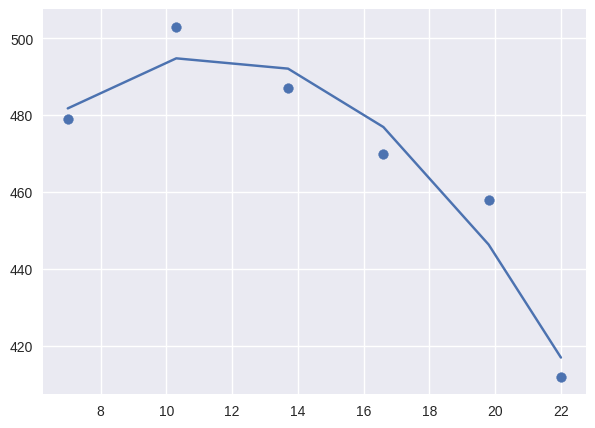

In [10]:
x = df['x']
plt.scatter(x, y)
plt.plot(x, ypred)

In [11]:
modelpo = sm.OLS(y, xp[:, 3:6]).fit()
print(modelpo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     22.51
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0156
Time:                        11:40:13   Log-Likelihood:                -20.339
No. Observations:                   6   AIC:                             46.68
Df Residuals:                       3   BIC:                             46.05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        403.2396     36.453     11.062      0.0

/home/thomas/Development/Git/statistical-inference-modeling/.venv/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [12]:
#@title resposta b)
#calcular SQE--> Baseado nos valores esperados
sqe = np.sum((ypred - y) ** 2)
print("SQE=", sqe)

#calcular SQT-->Baseado nos valores observados
sqt = np.sum((y - y.mean()) ** 2)
print("SQT=", sqt)

#calcular SQR
sqr = sqt - sqe
print("SQR=", sqr)

R2 = 1 - sqe / sqt
print("Coeficiente de determinação múltippla=", R2, "ou", R2 * 100, "%")

k = modelpo.df_model  # grau do modelo
n = modelpo.nobs  # num. amostras
R2adj = ((n - 1) * R2 - k) / (n - 1 - k)

print("R2 ajustado=", R2adj, "ou", R2adj * 100, "%")

SQE= 309.10898960300113
SQT= 4946.833333333333
SQR= 4637.724343730332
Coeficiente de determinação múltippla= 0.937513765115124 ou 93.75137651151239 %
R2 ajustado= 0.8958562751918734 ou 89.58562751918734 %


In [13]:
r2d = modelpo.rsquared
r2adjd = modelpo.rsquared_adj
print('R2= {0}, R2 ajustado= {1}'.format(r2d, r2adjd))

R2= 0.9375137651151241, R2 ajustado= 0.8958562751918735


# Resposta c)

IC de $\mu_{Y,13,7}$ pode se calcular com $\hat{Y} \pm t_{\frac{\alpha}{2},(n-(k+1))} s_{\hat{Y}} $

$s^2=\frac{SQE}{n-(k+1)}$



In [14]:
x = df['x']
xs = 13.7
xm = x.mean()
uy13 = 492.1155
xs, xm, uy13

(13.7, np.float64(14.9), 492.1155)

In [15]:
#usar a tabela tstudent pata t
from scipy.stats import t

alpha = 0.05  # significia = 5%
df = n - (k + 1)  # graus de liberdade
v = t.ppf(1 - alpha / 2, df)
tt = v
print(f't_crit=: {v}')

t_crit=: 3.1824463052837078


In [16]:
#@title Resposta d)
#usar a tabela tstudent pata t
from scipy.stats import t

alpha = 0.01  # significia = 1%
df = n - (k + 1)  # graus de liberdade
v = t.ppf(1 - alpha / 2, df)
tt = v
print(f't_crit=: {v}')

t_crit=: 5.840909309733355


In [17]:
s2 = sqe / (n - (k + 1))
s = pow(s2, 1 / 2)
s

np.float64(10.150681251407072)

In [18]:
#aux
#sxx=np.sum(x*x)-(np.sum(x)*np.sum(x))/n
#sy=s*pow(((1/n)+((xs-xm)*(xs-xm))/sxx),1/2)
#modelpo.fittedvalues
#modelpo.

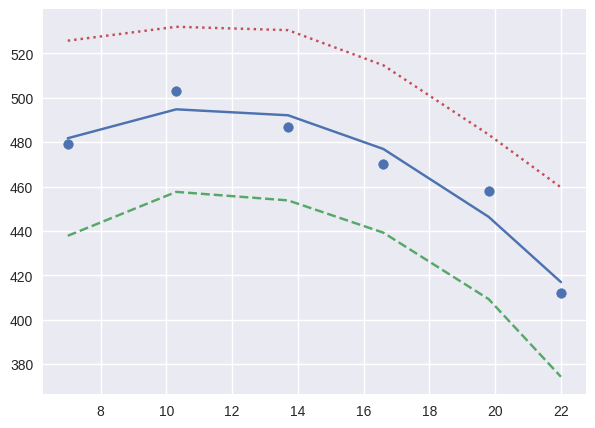

In [19]:
#Intervalos 
from statsmodels.sandbox.regression.predstd import wls_prediction_std

_, upper, lower = wls_prediction_std(modelpo)
plt.scatter(x, y)
plt.plot(x, ypred)
plt.plot(x, upper, '--', label="Maior")  # confid. intrvl
plt.plot(x, lower, ':', label="Menor")